# 43 - Metrics on a Real Model (Wine)

**Section:** Model Evaluation | **Prereqs:** `Model Evaluation/ARPF.ipynb` | **Next:** `Model Evaluation/ARPF_MNIST.ipynb`

The metrics from the previous notebook, computed on an actual trained classifier
with `sklearn.metrics`, plus the two summary tools you will use constantly:

- **`classification_report`** - precision, recall, F1 and support per class, in
  one call. Print this instead of accuracy, always.
- **`confusion_matrix`** - the raw four (or C x C) counts. It answers 'what is
  the model confusing with what', which no scalar metric can.

**Compute metrics on train AND test.** Precision holding up on train but
collapsing on test means the model memorised the positives.

**Argument order matters.** sklearn's signature is `metric(y_true, y_pred)`.
Accuracy and F1 are symmetric, so reversing them is harmless; **precision and
recall swap into each other**, and nothing warns you - both arguments are just
arrays of labels. Every call below passes truth first.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import torch

import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

%matplotlib inline

# https://archive.ics.uci.edu/

In [ ]:
!pip install ucimlrepo

In [ ]:
# Wine quality, with extreme total_sulfur_dioxide outliers (>200) dropped.
# Note the filter is applied to y BEFORE X is filtered, which works only because
# the mask is computed from the still-unfiltered X on both lines - fragile, but
# correct here.
from ucimlrepo import fetch_ucirepo

# fetch dataset
wine_quality = fetch_ucirepo(id=186)

# data (as pandas dataframes)
X = wine_quality.data.features
y = wine_quality.data.targets

y = y[X['total_sulfur_dioxide']<200]
X = X[X['total_sulfur_dioxide']<200]

cols = X.columns
X

,fixed_acidity,volatile_acidity,citric_acid,residual_sugar,chlorides,free_sulfur_dioxide,total_sulfur_dioxide,density,pH,sulphates,alcohol
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.99780,3.51,0.56,9.4
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.99680,3.20,0.68,9.8
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.99700,3.26,0.65,9.8
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.99800,3.16,0.58,9.8
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.99780,3.51,0.56,9.4
...,...,...,...,...,...,...,...,...,...,...,...
6492,6.2,0.21,0.29,1.6,0.039,24.0,92.0,0.99114,3.27,0.50,11.2
6493,6.6,0.32,0.36,8.0,0.047,57.0,168.0,0.99490,3.15,0.46,9.6
6494,6.5,0.24,0.19,1.2,0.041,30.0,111.0,0.99254,2.99,0.46,9.4
6495,5.5,0.29,0.30,1.1,0.022,20.0,110.0,0.98869,3.34,0.38,12.8


In [ ]:
y

,quality
0,5
1,5
2,5
3,6
4,5
...,...
6492,6
6493,5
6494,6
6495,7


In [ ]:
# Binarise at quality > 5.
y['Bool'] = (y['quality'] > 5).astype(int)
y

/tmp/ipython-input-279166436.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  y['Bool'] = (y['quality'] > 5).astype(int)


,quality,Bool
0,5,0
1,5,0
2,5,0
3,6,1
4,5,0
...,...,...
6492,6,1
6493,5,0
6494,6,1
6495,7,1


In [ ]:
y = y.drop(columns=['quality'])
y

,Bool
0,0
1,0
2,0
3,1
4,0
...,...
6492,1
6493,0
6494,1
6495,1


In [ ]:
# The class balance. Check this before choosing metrics - roughly balanced here,
# so accuracy is not completely meaningless, but precision/recall still say more.
y.value_counts()

,count
Bool,
1,3911
0,2175


In [ ]:
# The scaler is created here but FITTED after the split, in the next cell -
# fitting it on all the data would leak test statistics into the pipeline.
scaler = StandardScaler()
X = X.to_numpy()

In [ ]:
# 90/10 split, batches of 32.
# Split first, then fit the scaler on the training half and transform both.
X_train, X_test, Y_train, Y_test = train_test_split(X, y.to_numpy(), test_size=0.10)

X_train = torch.tensor(scaler.fit_transform(X_train),dtype=torch.float,device='cuda')
X_test  = torch.tensor(scaler.transform(X_test),     dtype=torch.float,device='cuda')
Y_train = torch.tensor(Y_train,dtype=torch.float,device='cuda')
Y_test  = torch.tensor(Y_test, dtype=torch.float,device='cuda')

train_data = TensorDataset(X_train, Y_train)
test_data = TensorDataset(X_test,Y_test)

bs =32

train_loader = DataLoader(train_data, batch_size=bs, shuffle=True, drop_last=True)
test_loader = DataLoader(test_data, batch_size=test_data.tensors[0].shape[0])

In [ ]:
# 11 -> 16 -> 16 -> 1, raw logit out for BCEWithLogitsLoss.
class model(nn.Module):
  def __init__(self):
    super().__init__()

    self.model = nn.Sequential(
        nn.Linear(11,16),
        nn.ReLU(),
        nn.Linear(16,16),
        nn.ReLU(),
        nn.Linear(16,1)
    )

  def forward(self,x):
    return self.model(x)

In [ ]:
# Training function, tracking overall accuracy plus per-class accuracy.
def train_model(train_loader, test_loader):

  classifier = model()
  classifier.to('cuda')

  lr = 0.01
  epochs = 50
  lossFunc = nn.BCEWithLogitsLoss()

  optimizer = torch.optim.SGD(classifier.parameters(),lr = lr)


  train_acc = []
  test_acc = []
  losses = []
  one_acc = []
  zero_acc = []

  for epoch in range(epochs):

    classifier.train()

    batch_acc = []
    batch_loss = []

    for x,y in train_loader:

      yhat = classifier(x)

      loss = lossFunc(yhat,y)
      batch_loss.append(loss.item())

      optimizer.zero_grad()
      loss.backward()
      optimizer.step()

      batch_acc.append(100 * torch.mean(((yhat > 0) == y).float().cpu()))

    losses.append(np.mean(batch_loss))
    train_acc.append(np.mean(batch_acc))

    classifier.eval()
    with torch.no_grad():

      # Here we calculate both total acc and accurcy based on class
      X,Y = next(iter(test_loader))
      preds = classifier(X)
      predVals = ((preds > 0) == Y).float()
      test_acc.append(100 * torch.mean(((preds > 0) == Y).float().cpu()))
      zero_acc.append(100 * torch.mean(predVals[Y == 0]).cpu())
      one_acc.append(100 * torch.mean(predVals[Y == 1]).cpu())


    if epoch % 10 == 0 or epoch == epochs - 1:
      print(f'Epoch {epoch} - Loss {losses[epoch]} - Val Accuracy : {test_acc[epoch]}')



  return train_acc, test_acc, losses, one_acc, zero_acc, classifier

In [ ]:
train_acc, test_acc, losses, one_acc, zero_acc, classifier = train_model(train_loader, test_loader)

Epoch 0 - Loss 0.6673342515850624 - Val Accuracy : 67.65188598632812
Epoch 10 - Loss 0.5313756657622711 - Val Accuracy : 74.712646484375
Epoch 20 - Loss 0.49907100496933476 - Val Accuracy : 77.83251190185547
Epoch 30 - Loss 0.49003723298597057 - Val Accuracy : 78.81773376464844
Epoch 40 - Loss 0.483199799967091 - Val Accuracy : 79.1461410522461
Epoch 49 - Loss 0.478689187799978 - Val Accuracy : 77.83251190185547


In [ ]:
# Predictions for the whole train and test splits, for metric computation.
inp = train_loader.dataset.tensors[0]
train_preds = classifier(inp)

inp_test = test_loader.dataset.tensors[0]
test_preds = classifier(inp_test)


In [ ]:
from sklearn.metrics import recall_score, accuracy_score, precision_score, f1_score, classification_report, confusion_matrix


In [ ]:
# Logits -> hard 0/1 decisions at the threshold logit > 0 (= probability > 0.5).
# Every metric below depends on this threshold; moving it moves precision and
# recall in opposite directions.
train_preds = (train_preds > 0).int().cpu()
train_label = train_loader.dataset.tensors[1].cpu()

test_preds = (test_preds > 0).int().cpu()
test_label = test_loader.dataset.tensors[1].cpu()

In [ ]:
# The four metrics for both splits.
# The argument order is (y_true, y_pred) and it is NOT optional: accuracy and F1
# are symmetric, but precision and recall swap into each other if you reverse
# them. sklearn cannot detect the mistake - both arguments are just label arrays.
acc_train = accuracy_score(train_label, train_preds)
recall_train = recall_score(train_label, train_preds)
precision_train = precision_score(train_label, train_preds)
f1_train = f1_score(train_label, train_preds)

acc_test = accuracy_score(test_label, test_preds)
recall_test = recall_score(test_label, test_preds)
precision_test = precision_score(test_label, test_preds)
f1_test = f1_score(test_label, test_preds)

<BarContainer object of 4 artists>

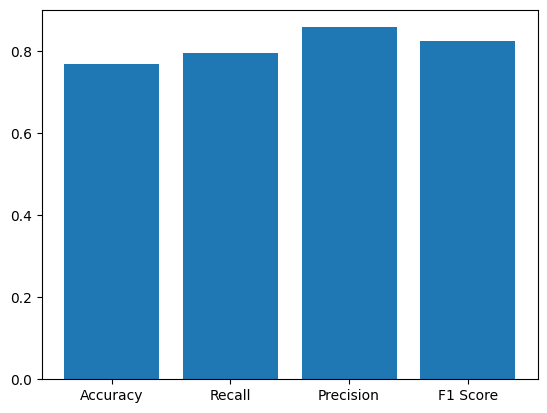

In [ ]:
# Train metrics as bars.
plt.bar(['Accuracy', 'Recall', "Precision", "F1 Score"], [acc_train, recall_train, precision_train, f1_train])


<BarContainer object of 4 artists>

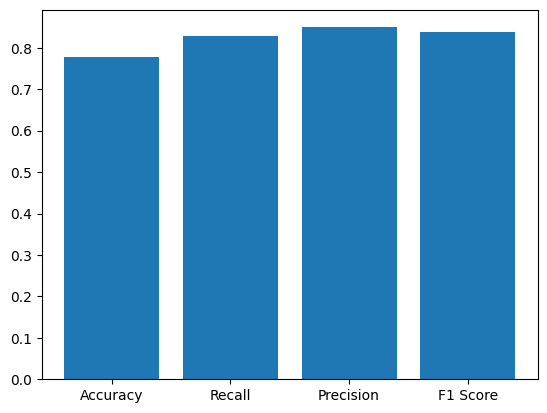

In [ ]:
# Test metrics as bars.
plt.bar(['Accuracy', 'Recall', "Precision", "F1 Score"], [acc_test, recall_test, precision_test, f1_test])

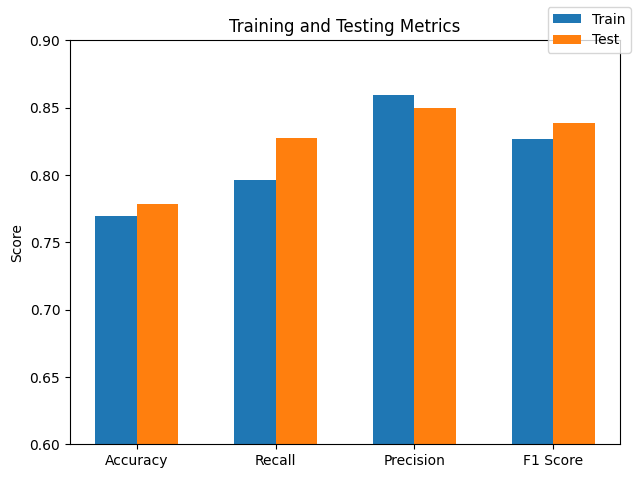

In [ ]:
# Train vs test side by side - the comparison that matters. A large drop in
# any bar from train to test is overfitting on that aspect of the problem.
# Note the y-axis starts at 0.6, which visually exaggerates the differences.
labels = ['Accuracy', 'Recall', "Precision", "F1 Score"]
train_metrics = [acc_train, recall_train, precision_train, f1_train]
test_metrics = [acc_test, recall_test, precision_test, f1_test]

x = np.arange(len(labels))  # the label locations
width = 0.3 # the width of the bars

fig, ax = plt.subplots()
rects1 = ax.bar(x - width/2, train_metrics, width, label='Train')
rects2 = ax.bar(x + width/2, test_metrics, width, label='Test')

# Add some text for labels, title and custom x-axis tick labels, etc.
ax.set_ylabel('Score')
ax.set_title('Training and Testing Metrics')
ax.set_xticks(x)
ax.set_xticklabels(labels)
fig.legend()
ax.set_ylim([.6,0.9])
fig.tight_layout()

plt.show()

In [ ]:
# classification_report: per-class precision, recall, F1 and support in one
# call. This is what to paste into a report.
print(classification_report(test_label, test_preds))

              precision    recall  f1-score   support

           0       0.63      0.67      0.65       186
           1       0.85      0.83      0.84       423

    accuracy                           0.78       609
   macro avg       0.74      0.75      0.74       609
weighted avg       0.78      0.78      0.78       609



In [ ]:
# average='weighted' averages the per-class scores in proportion to class size.
# Alternatives: 'macro' (unweighted, so rare classes count equally - usually
# what you want on imbalanced data) and 'micro' (pools all predictions).
precision_score(train_label, train_preds, average='weighted')

0.7821850894506537

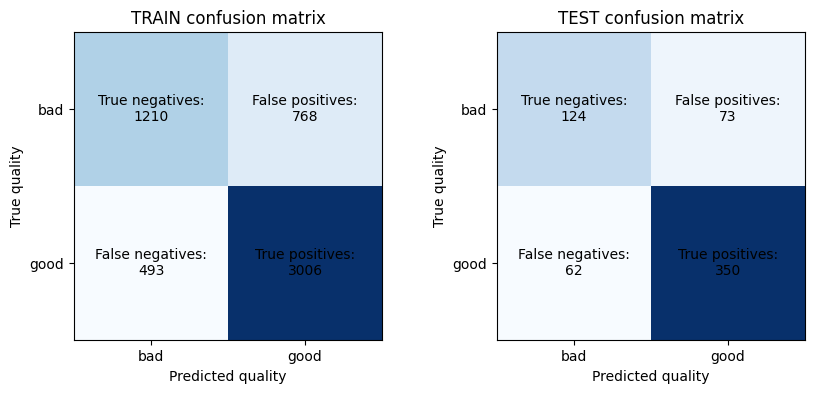

In [ ]:
# The confusion matrix, drawn with each cell labelled. Read it as:
#   diagonal = correct, off-diagonal = the mistakes and their direction.
# It answers questions no scalar can - such as whether the model fails by
# missing good wines or by over-predicting them.
# (These calls do pass (y_true, y_pred) in the right order.)
# Confusion matrices
trainConf = confusion_matrix(train_loader.dataset.tensors[1].cpu(),train_preds)
testConf  = confusion_matrix(test_loader.dataset.tensors[1].cpu(), test_preds)

fig,ax = plt.subplots(1,2,figsize=(10,4))

# confmat during TRAIN
ax[0].imshow(trainConf,'Blues',vmax=len(train_preds)/2)
ax[0].set_xticks([0,1])
ax[0].set_yticks([0,1])
ax[0].set_xticklabels(['bad','good'])
ax[0].set_yticklabels(['bad','good'])
ax[0].set_xlabel('Predicted quality')
ax[0].set_ylabel('True quality')
ax[0].set_title('TRAIN confusion matrix')

# add text labels
ax[0].text(0,0,f'True negatives:\n{trainConf[0,0]}' ,ha='center',va='center')
ax[0].text(0,1,f'False negatives:\n{trainConf[1,0]}',ha='center',va='center')
ax[0].text(1,1,f'True positives:\n{trainConf[1,1]}' ,ha='center',va='center')
ax[0].text(1,0,f'False positives:\n{trainConf[0,1]}',ha='center',va='center')




# confmat during TEST
ax[1].imshow(testConf,'Blues',vmax=len(test_preds)/2)
ax[1].set_xticks([0,1])
ax[1].set_yticks([0,1])
ax[1].set_xticklabels(['bad','good'])
ax[1].set_yticklabels(['bad','good'])
ax[1].set_xlabel('Predicted quality')
ax[1].set_ylabel('True quality')
ax[1].set_title('TEST confusion matrix')

# add text labels
ax[1].text(0,0,f'True negatives:\n{testConf[0,0]}' ,ha='center',va='center')
ax[1].text(0,1,f'False negatives:\n{testConf[1,0]}',ha='center',va='center')
ax[1].text(1,1,f'True positives:\n{testConf[1,1]}' ,ha='center',va='center')
ax[1].text(1,0,f'False positives:\n{testConf[0,1]}',ha='center',va='center')
plt.show()


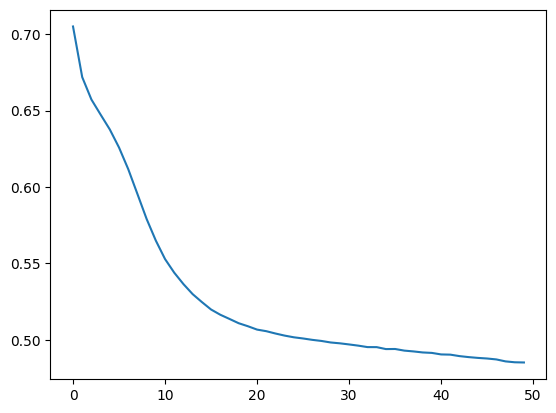

In [ ]:
# The loss curve, for reference.
plt.plot(losses);